# Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

Introduction
●	To perform descriptive analytics, visualize data distributions, and preprocess the dataset for further analysis.

# Descriptive Analytics for Numerical Columns
 ●	Objective: To compute and analyze basic statistical measures for numerical columns in the dataset.
 ●	Steps:
	Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).
	Identify numerical columns in the dataset.
	Calculate the mean, median, mode, and standard deviation for these columns.
	Provide a brief interpretation of these statistics.

In [3]:
import pandas as pd
from scipy import stats

# Load Dataset 
df = pd.read_csv('sales_data_with_discounts.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [4]:
df.head() # To Display first 5 rows of dataset

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [5]:
df.tail() # To Display last 5 rows of dataset

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103758
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174
449,15-04-2021,Thursday,L10,C,1,Lifestyle,Jeera,M-Shoes,3100,3100,15.333300,475.332295,2624.667705


In [8]:
# Identify numerical columns in dataset
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:", numerical_cols)

Numerical Columns: Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')


Interpretation of statistics :
1. Mean → Average value of the column. Gives a central tendency.
2. Median → Middle value when data is sorted. Less affected by outliers than mean.
3. Mode → Most frequently occurring value. Useful for categorical-like numerical data.
4. Standard Deviation (SD) → Measures the spread or dispersion of the data. Higher SD → values are more spread out.

In [20]:
# Calculating the mean, median, mode, and standard deviation for these columns.
print ('_'*50)
for col in numerical_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]  # First mode if multiple
    std_val = df[col].std()
    
    print(f"\nColumn: {col}")
    print(f"Mean of {col}: {round(mean_val,2)}") # round(___,2) function used to round of answer in 2 decimal places
    print(f"Median of {col}: {round(median_val,2)}")
    print(f"Mode of {col}: {mode_val}")
    print(f"Standard Deviation of {col}: {round(std_val,2)}")
    

    print ('_'*50)

__________________________________________________

Column: Volume
Mean of Volume: 5.07
Median of Volume: 4.0
Mode of Volume: 3
Standard Deviation of Volume: 4.23
__________________________________________________

Column: Avg Price
Mean of Avg Price: 10453.43
Median of Avg Price: 1450.0
Mode of Avg Price: 400
Standard Deviation of Avg Price: 18079.9
__________________________________________________

Column: Total Sales Value
Mean of Total Sales Value: 33812.84
Median of Total Sales Value: 5700.0
Mode of Total Sales Value: 24300
Standard Deviation of Total Sales Value: 50535.07
__________________________________________________

Column: Discount Rate (%)
Mean of Discount Rate (%): 15.16
Median of Discount Rate (%): 16.58
Mode of Discount Rate (%): 5.007822189204133
Standard Deviation of Discount Rate (%): 4.22
__________________________________________________

Column: Discount Amount
Mean of Discount Amount: 3346.5
Median of Discount Amount: 988.93
Mode of Discount Amount: 69.1779422

Interpretation of these statistics :
1. Mean of Volume is 5.07 i.e. average number of Volumes sale on different dates, of different Brand, of different Model is 5.
2. Mode of Avg Price: 400 i.e. Maximum sales item have Avg price is 400
3. Standard Deviation of Total Sales Value: 50535.07 i.e. high deviation in Total Sales Value.
4. Standard Deviation of Volume: 4.23 i.e. less deviation in Volume. So we can say that approx volume is 5, there was less sales that have different Volume. 
5. Mean of Discount Rate (%): 15.16, Median of Discount Rate (%): 16.58 and Mode of Discount Rate (%): 5.01 i.e. average dicount rate is 15.16 % and median is 16.58 % (Middle Value of Discount Rate). Discount Rate given more frequently is 5 %.

# Data Visualization
●	Objective: To visualize the distribution and relationship of numerical and categorical variables in the dataset.

●	Histograms:
	Plot histograms for each numerical column.
	Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.

Volume


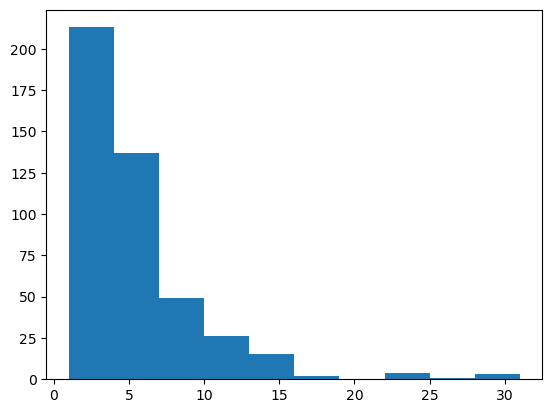

___________________________________________________________________________
Avg Price


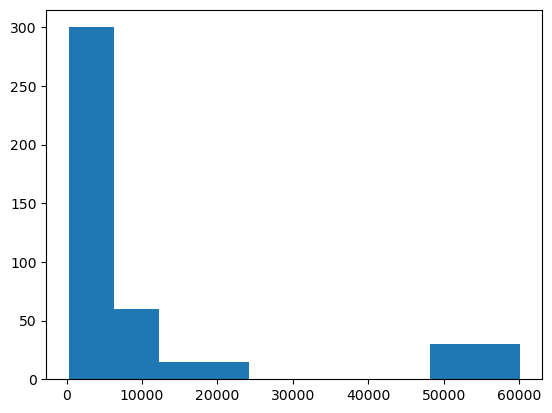

___________________________________________________________________________
Total Sales Value


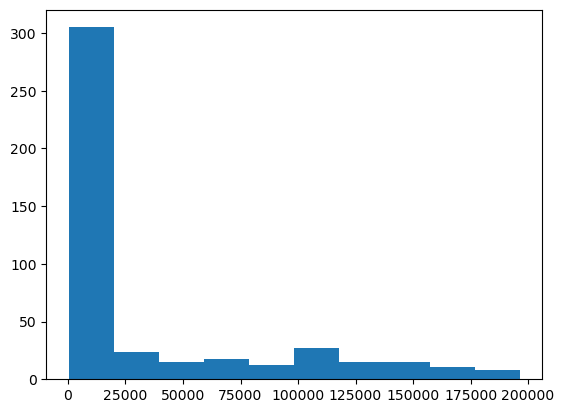

___________________________________________________________________________
Discount Rate (%)


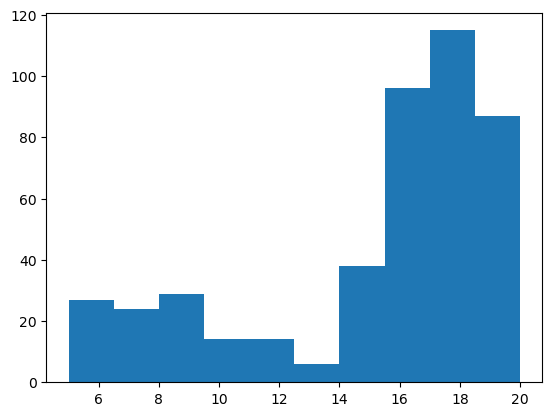

___________________________________________________________________________
Discount Amount


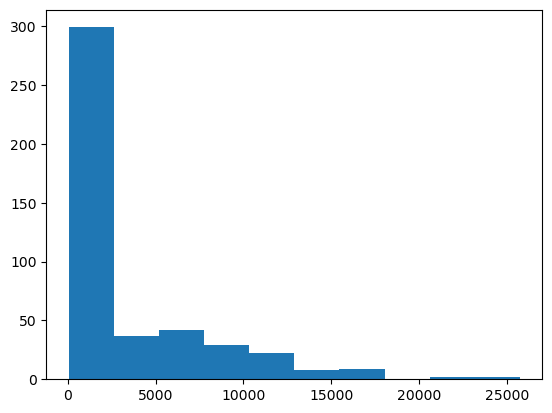

___________________________________________________________________________
Net Sales Value


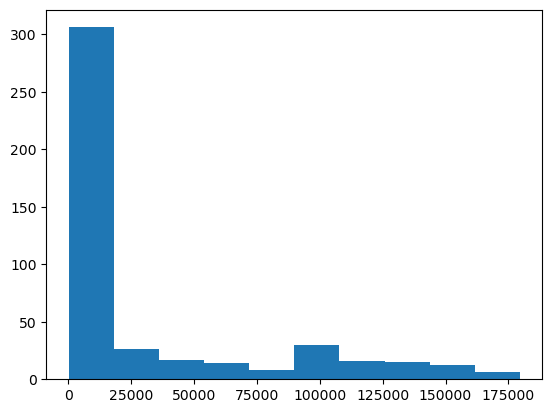

___________________________________________________________________________


In [24]:
import matplotlib.pyplot as plt 
for col in numerical_cols:
    print(col)
    plt.hist(df[col]) # For Histogram
    plt.show()
    print ('_'*75)

Interpretations:
1. For Volume : It is positively skewed i.e. most values of Volume on the left side. And we can see here presence of outliers.
2. For Avg Price : It is positively skewed i.e. most values of Avg Price on the left side. And we can see here presence of outliers at right side.
3. For Total Sales Value : It is positively skewed i.e. most values of Total Sales Value on the left side. And we can see here presence of outliers at right side.
4. For Discount Rate : It is negatively skewed i.e. most values of Discount Rate on the Right side. And we can see here presence of outliers at left side.
5. For Discount Amount : It is positively skewed i.e. most values of Discount Amount on the left side. And we can see here presence of outliers at right side.
6. For Net Sales Value : It is positively skewed. And we can see here presence of outliers at right side.

A positively skewed (or right-skewed) distribution has a long tail to the right, with most values on the left, resulting in Mean > Median > Mode. 
A negatively skewed (or left-skewed) distribution has a long tail to the left, with most values on the right, leading to Mean < Median < Mode. 

●	Box Plots:
	Create boxplots for numerical variables to identify outliers and the interquartile range.
	Discuss any findings, such as extreme values or unusual distributions.

Volume


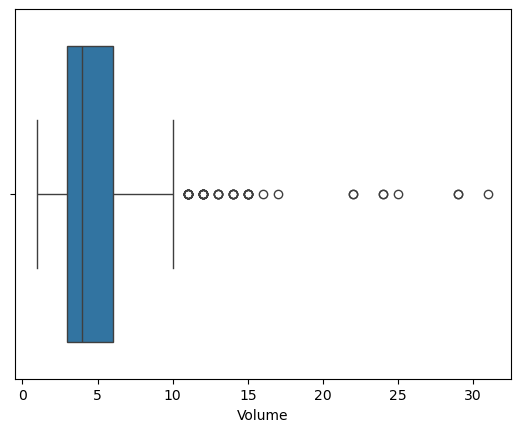

___________________________________________________________________________
Avg Price


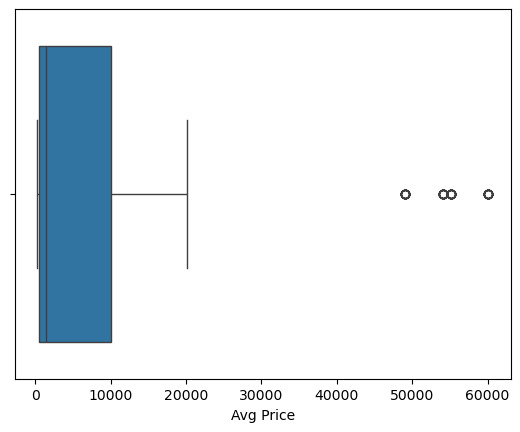

___________________________________________________________________________
Total Sales Value


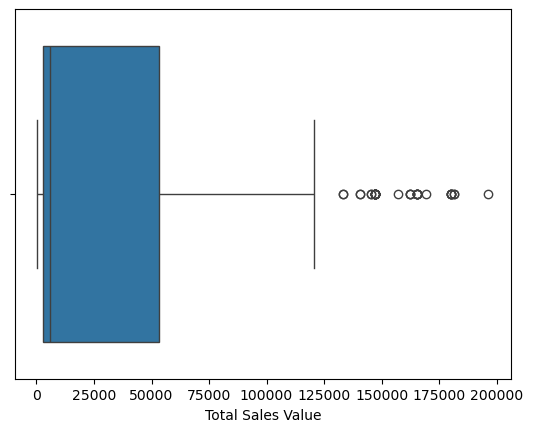

___________________________________________________________________________
Discount Rate (%)


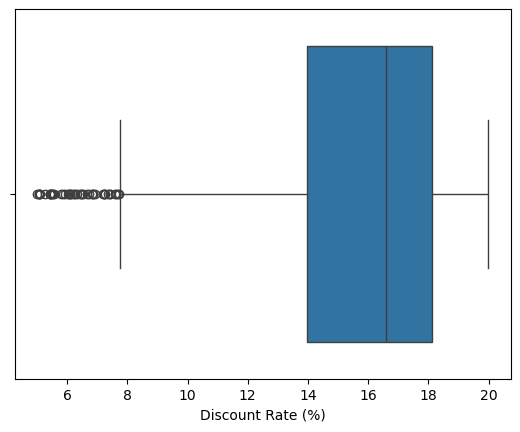

___________________________________________________________________________
Discount Amount


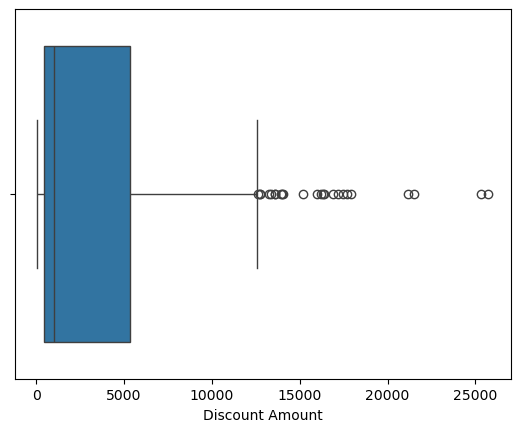

___________________________________________________________________________
Net Sales Value


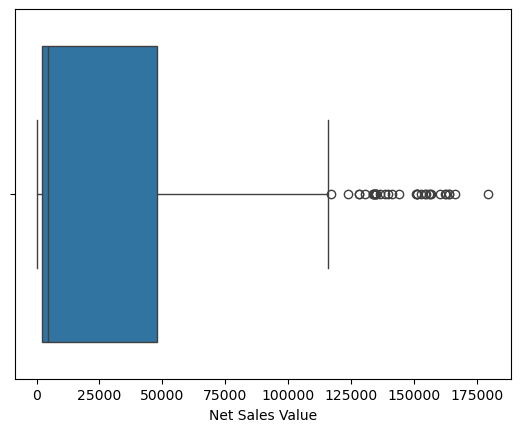

___________________________________________________________________________


In [26]:
import seaborn as sns
for col in numerical_cols:
    print(col)
    sns.boxplot(df, x=col) # For Boxplot
    plt.show()
    print ('_'*75)

From Boxplot we can see Points plotted outside the whiskers which are nothing but outliers.
Line in box denote median.
Form size of box we can is dispersion in variables like in Volume there are less dispersion and in Net Sales Value there are more dispersion.
Skewness also study form this plot i.e. Expect Discount Rate all are Positively Skewed.

●	Bar Chart Analysis for Categorical Column:
	Identify categorical columns in the dataset.
	Create bar charts to visualize the frequency or count of each category.
	Analyze the distribution of categories and provide insights.

Categorical Columns: Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')
Date


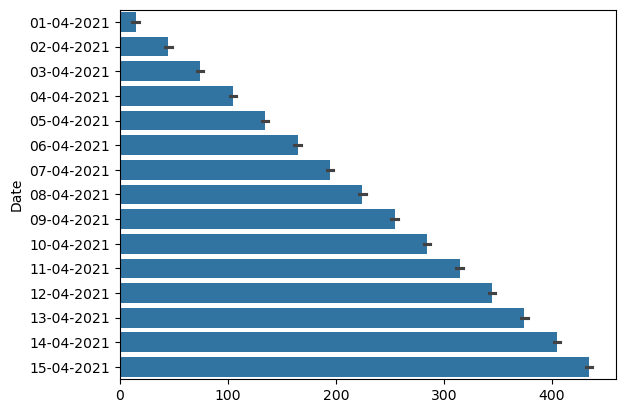

___________________________________________________________________________
Day


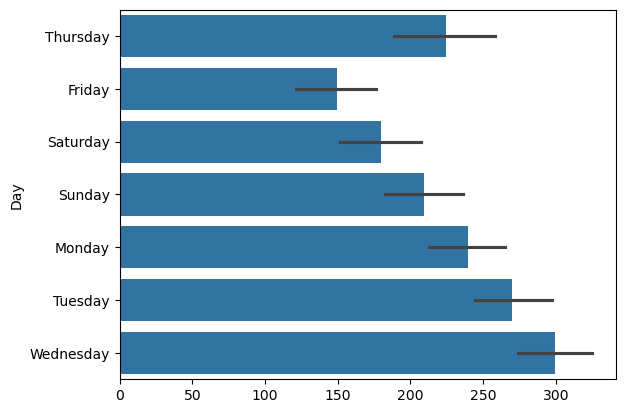

___________________________________________________________________________
SKU


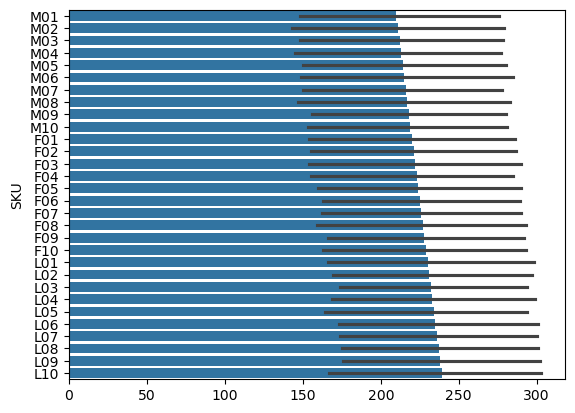

___________________________________________________________________________
City


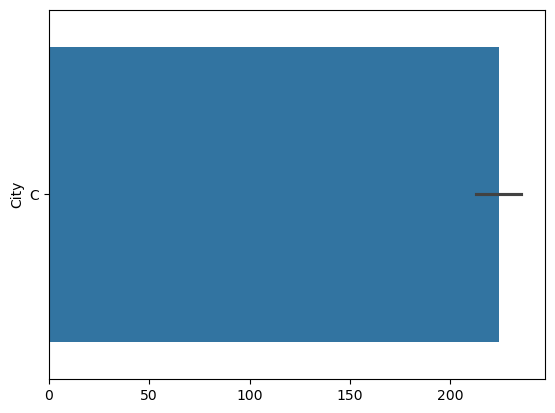

___________________________________________________________________________
BU


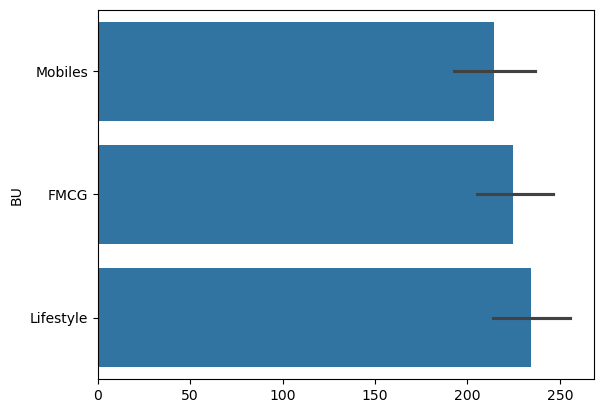

___________________________________________________________________________
Brand


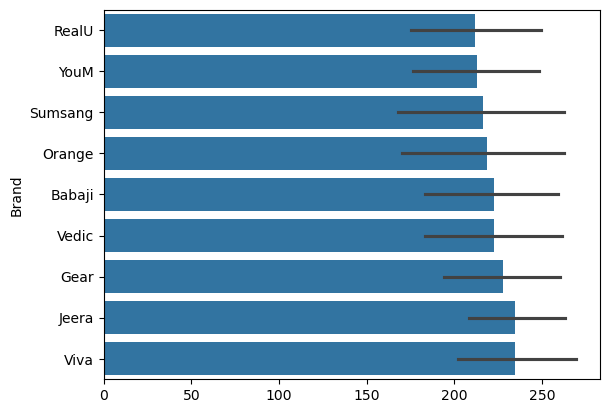

___________________________________________________________________________
Model


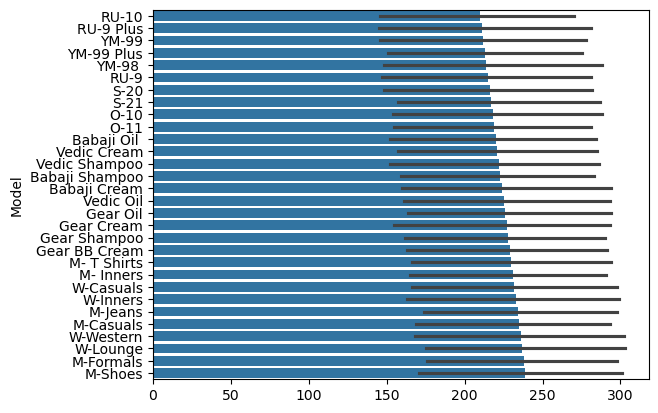

___________________________________________________________________________


In [33]:
# Identifing categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", categorical_cols)
for col in categorical_cols:
    print(col)
    sns.barplot(df[col]) #For Barplot
    plt.show()
    print ('_'*75)

From Barplot we can know about frequencies of categories like in Brand there is Viva and Jeera top brands, sales of MOdel M-shoes is more etc.
We can know trend of sales like by Column Day we got to know that Wednesday had highest Sales compare to other days.